In [37]:
import time
import warnings
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.utils import resample
from sklearn.exceptions import ConvergenceWarning
from scipy.stats import uniform, randint, loguniform, t, sem
import tensorflow as tf
import keras_tuner as kt
from pyMAISE.datasets import load_MITR, load_chf

# Set display option to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Set the width of the columns
pd.set_option('display.width', None)

# See the full content of each column
pd.set_option('display.max_colwidth', None)

# Plot settings
matplotlib_settings = {
    "font.size": 12,
    "legend.fontsize": 11,
    "figure.figsize": (12, 8)
}
plt.rcParams.update(**matplotlib_settings)

# Suppress all ConvergenceWarnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

print('libraries imported and settings configured')

libraries imported and settings configured


# Workflow Section

In [38]:
# load data

# Helper func for ensuring y is 2D
def ensure_2d_targets(y):
    y = np.asarray(y)
    if y.ndim == 1:
        return y.reshape(-1, 1)
    return y

is_single_output = True # Select single or multi output dataset

data = []
inputs = []
outputs = []

if is_single_output:
    train_data, train_inputs, train_outputs = load_chf(data_path='datasets/chf_train_synth.csv')
    test_data, test_inputs, test_outputs = load_chf(data_path='datasets/chf_test_synth.csv')
    data = np.concat([train_data, test_data])
    inputs = np.asarray(np.concat([train_inputs, test_inputs]))
    outputs = ensure_2d_targets(np.concat([train_outputs, test_outputs]))
    print('Single-output dataset selected (CHF)')
else:
    data, inputs, outputs = load_MITR()
    print('Multi-output dataset selected (MITR)')

print('-'*40)
print(f'data shape: {data.shape}')
print(f'inputs shape: {inputs.shape}')
print(f'outputs shape: {outputs.shape}')

print('\nData loading complete')

Single-output dataset selected (CHF)
----------------------------------------
data shape: (2500, 7)
inputs shape: (2500, 6)
outputs shape: (2500, 1)

Data loading complete


In [61]:
# Data Bias: Create k-fold cv on train/test sets.
k = 3 # number of train-test splits and ratio size
epochs=10

kf = KFold(n_splits=k, shuffle=True, random_state=42)
X_train_sets = []
X_test_sets = []
Y_train_sets = []
Y_test_sets = []

for train_index, test_index in kf.split(inputs):
    X_train_sets.append(inputs[train_index])
    X_test_sets.append(inputs[test_index])
    Y_train_sets.append(outputs[train_index])
    Y_test_sets.append(outputs[test_index])

def fold_shapes(folds):
    shapes = [fold.shape for fold in folds]
    return (len(folds), *shapes[0]) if len(set(shapes)) == 1 else shapes

print(f'Number of train/test splits: {k}')
print('-'*40)
print(f'X_train shapes: {fold_shapes(X_train_sets)}')
print(f'Y_train shapes: {fold_shapes(Y_train_sets)}')
print(f'X_test shapes:  {fold_shapes(X_test_sets)}')
print(f'Y_test shapes:  {fold_shapes(Y_test_sets)}')

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("fnn", MLPRegressor(max_iter=epochs, random_state=42))
])

model = TransformedTargetRegressor(
    regressor=pipe,
    transformer=StandardScaler()
)

print('\nData preprocessing complete')

Number of train/test splits: 3
----------------------------------------
X_train shapes: [(1666, 6), (1667, 6), (1667, 6)]
Y_train shapes: [(1666, 1), (1667, 1), (1667, 1)]
X_test shapes:  [(834, 6), (833, 6), (833, 6)]
Y_test shapes:  [(834, 1), (833, 1), (833, 1)]

Data preprocessing complete


In [40]:
# Model Bias: Define hyper parameter distributions for random search.
wide_layer_sizes = [
    (64,), (128,), (256,), (512,),
    (128, 128), (256, 256),
    (128, 64), (256, 128),
    (512, 256), (256, 128, 64),
]
narrow_layer_sizes = [
    (8,), (16,), (32,),
    (16, 8), (32, 16),
    (32, 16, 8), (16, 16),
    (24, 12), (12, 12, 12),
    (32, 24, 16),
]
taper_layer_sizes = [
    (256, 128, 64),
    (512, 256, 128),
    (256, 128, 64, 32),
    (128, 64, 32, 16),
    (512, 256, 128, 64),
    (256, 128, 64, 32, 16),
    (128, 96, 64, 32),
    (256, 192, 128, 64),
    (384, 256, 128),
    (192, 128, 64, 32),
]
rev_taper_layer_sizes = [
    (32, 64, 128),
    (64, 128, 256),
    (16, 32, 64, 128),
    (32, 64, 128, 256),
    (8, 16, 32, 64),
    (16, 32, 64, 128, 256),
    (24, 48, 96),
    (32, 96, 192),
    (64, 128, 256, 512),
    (32, 64, 128, 256, 512),
]
bowtie_layer_sizes = [
    (128, 32, 128),
    (256, 64, 256),
    (128, 64, 32, 64, 128),
    (256, 128, 64, 128, 256),
    (64, 16, 64),
    (128, 32, 16, 32, 128),
    (256, 64, 32, 64, 256),
    (192, 64, 192),
    (128, 48, 24, 48, 128),
    (256, 96, 48, 96, 256),
]

activation = ["relu", "tanh"]
alpha = loguniform(1e-5, 1e-1)
learning_rate_init = loguniform(1e-4, 1e-2)
solver = ["adam", 'lbfgs']
early_stopping = [True]
validation_fraction = [0.1]

n_iter = 5
scoring = "r2"
cv = 5
verbose = 1
random_state = 42
n_jobs = -1

wide_fnn_param_dist = {
    "regressor__fnn__hidden_layer_sizes": wide_layer_sizes,
    "regressor__fnn__activation": activation,
    "regressor__fnn__alpha": alpha,
    "regressor__fnn__learning_rate_init": learning_rate_init,
    "regressor__fnn__solver": solver,
    "regressor__fnn__early_stopping": early_stopping,
    "regressor__fnn__validation_fraction": validation_fraction,
}

narrow_fnn_param_dist = {
    "regressor__fnn__hidden_layer_sizes": narrow_layer_sizes,
    "regressor__fnn__activation": activation,
    "regressor__fnn__alpha": alpha,
    "regressor__fnn__learning_rate_init": learning_rate_init,
    "regressor__fnn__solver": solver,
    "regressor__fnn__early_stopping": early_stopping,
    "regressor__fnn__validation_fraction": validation_fraction,
}

taper_fnn_param_dist = {
    "regressor__fnn__hidden_layer_sizes": taper_layer_sizes,
    "regressor__fnn__activation": activation,
    "regressor__fnn__alpha": alpha,
    "regressor__fnn__learning_rate_init": learning_rate_init,
    "regressor__fnn__solver": solver,
    "regressor__fnn__early_stopping": early_stopping,
    "regressor__fnn__validation_fraction": validation_fraction,
}

rev_taper_fnn_param_dist = {
    "regressor__fnn__hidden_layer_sizes": rev_taper_layer_sizes,
    "regressor__fnn__activation": activation,
    "regressor__fnn__alpha": alpha,
    "regressor__fnn__learning_rate_init": learning_rate_init,
    "regressor__fnn__solver": solver,
    "regressor__fnn__early_stopping": early_stopping,
    "regressor__fnn__validation_fraction": validation_fraction,
}

bowtie_fnn_param_dist = {
    "regressor__fnn__hidden_layer_sizes": bowtie_layer_sizes,
    "regressor__fnn__activation": activation,
    "regressor__fnn__alpha": alpha, #regularization
    "regressor__fnn__learning_rate_init": learning_rate_init,
    "regressor__fnn__solver": solver,
    "regressor__fnn__early_stopping": early_stopping,
    "regressor__fnn__validation_fraction": validation_fraction,
}

wide_fnn_random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=wide_fnn_param_dist,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    verbose=verbose,
    random_state=random_state,
    n_jobs=n_jobs
)

narrow_fnn_random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=narrow_fnn_param_dist,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    verbose=verbose,
    random_state=random_state,
    n_jobs=n_jobs
)

taper_fnn_random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=taper_fnn_param_dist,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    verbose=verbose,
    random_state=random_state,
    n_jobs=n_jobs
)

rev_taper_fnn_random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=rev_taper_fnn_param_dist,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    verbose=verbose,
    random_state=random_state,
    n_jobs=n_jobs
)

bowtie_fnn_random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=bowtie_fnn_param_dist,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    verbose=verbose,
    random_state=random_state,
    n_jobs=n_jobs
)

print('Hyperparameter definitions completed')

Hyperparameter definitions completed


In [41]:
# Sampling Bias: Generate multiple training sets with different sampling methods.
def make_bootstrap_train_sets(X_train_sets, Y_train_sets, n_sets=5, random_state=42):
    X_boot_train_sets = []
    Y_boot_train_sets = []
    for j in range(n_sets): # n bootstrap samples per train set
        X_boot_folds = []
        Y_boot_folds = []
        for X_train, Y_train in zip(X_train_sets, Y_train_sets):
            X_boot, Y_boot = resample(
                X_train,
                Y_train,
                n_samples=X_train.shape[0],
                replace=True,
                random_state=random_state
            )
            X_boot_folds.append(X_boot)
            Y_boot_folds.append(Y_boot)
        X_boot_train_sets.append(X_boot_folds)
        Y_boot_train_sets.append(Y_boot_folds)
    return X_boot_train_sets, Y_boot_train_sets

def make_strata(Y, n_bins=2):
    Y = np.asarray(Y)
    binned_outputs = []
    for i in np.arange(Y.shape[1]):
        target_col = Y[:, i]
        edges = np.quantile(
            target_col,
            np.linspace(0, 1, n_bins + 1)
        )
        edges = np.unique(edges)
        binned_col = np.digitize(
            target_col,
            edges[1:-1],
            right=True
        )
        binned_outputs.append(binned_col)
    binned_outputs = np.column_stack(binned_outputs)
    strata = np.array([
        '_'.join(map(str, row))
        for row in binned_outputs
    ])
    return strata
    
def make_stratified_bootstrap_train_sets(X_train_sets, Y_train_sets, n_sets=5, random_state=42):
    X_boot_stratified_train_sets = []
    Y_boot_stratified_train_sets = []
    for j in range(n_sets):
        X_boot_stratified_folds = []
        Y_boot_stratified_folds = []
        for X_train, Y_train in zip(X_train_sets, Y_train_sets):
            X_boot_stratified, Y_boot_stratified = resample(
                X_train, 
                Y_train, 
                replace=True,
                n_samples=X_train.shape[0],
                stratify=make_strata(Y_train),
                random_state=random_state
            )
            X_boot_stratified_folds.append(X_boot_stratified)
            Y_boot_stratified_folds.append(Y_boot_stratified)
        X_boot_stratified_train_sets.append(X_boot_stratified_folds)
        Y_boot_stratified_train_sets.append(Y_boot_stratified_folds)
    return X_boot_stratified_train_sets, Y_boot_stratified_train_sets

print('Sampling functions defined')

Sampling functions defined


In [42]:
# Generate new train sets with different sampling methods 
n_sets = 3 # number of sampled train sets to generate per method (2 methods total)

X_bootstrap_train_sets, Y_bootstrap_train_sets = make_bootstrap_train_sets(X_train_sets, Y_train_sets, n_sets=n_sets)
X_stratified_train_sets, Y_stratified_train_sets = make_stratified_bootstrap_train_sets(X_train_sets, Y_train_sets, n_sets=n_sets)

def sampled_fold_shapes(sampled_folds):
    shapes = [fold_shapes(folds) for folds in sampled_folds]
    return (len(sampled_folds), shapes[0]) if len(set(map(str, shapes))) == 1 else shapes

print('Sampling method | X and Y train set shapes')
print('-'*60)
print('None             ', fold_shapes(X_train_sets), fold_shapes(Y_train_sets))
print('Bootstrap        ', sampled_fold_shapes(X_bootstrap_train_sets), sampled_fold_shapes(Y_bootstrap_train_sets))
print('Stratified       ', sampled_fold_shapes(X_stratified_train_sets), sampled_fold_shapes(Y_stratified_train_sets))

train_sets = []
for i, (X_train, Y_train) in enumerate(zip(X_train_sets, Y_train_sets)):
    train_sets.append({
        'set_index': i,
        'sampled_set_index': 0,
        'sampling_method': 'none',
        'X_train_set': X_train,
        'Y_train_set': Y_train,
    })
for sampled_set_index, (sampled_folds_X, sampled_folds_Y) in enumerate(zip(X_bootstrap_train_sets, Y_bootstrap_train_sets)):
    for j, (X_train, Y_train) in enumerate(zip(sampled_folds_X, sampled_folds_Y)):
        train_sets.append({
            'set_index': j,
            'sampled_set_index': sampled_set_index,
            'sampling_method': 'bootstrap',
            'X_train_set': X_train,
            'Y_train_set': Y_train,
        })
for sampled_set_index, (sampled_folds_X, sampled_folds_Y) in enumerate(zip(X_stratified_train_sets, Y_stratified_train_sets)):
    for j, (X_train, Y_train) in enumerate(zip(sampled_folds_X, sampled_folds_Y)):
        train_sets.append({
            'set_index': j,
            'sampled_set_index': sampled_set_index,
            'sampling_method': 'stratified',
            'X_train_set': X_train,
            'Y_train_set': Y_train,
        })
train_sets = pd.DataFrame(train_sets)

print('\nTotal train sets:', train_sets.shape[0])

print('\nSampled train sets created')

Sampling method | X and Y train set shapes
------------------------------------------------------------
None              [(1666, 6), (1667, 6), (1667, 6)] [(1666, 1), (1667, 1), (1667, 1)]
Bootstrap         (3, [(1666, 6), (1667, 6), (1667, 6)]) (3, [(1666, 1), (1667, 1), (1667, 1)])
Stratified        (3, [(1666, 6), (1667, 6), (1667, 6)]) (3, [(1666, 1), (1667, 1), (1667, 1)])

Total train sets: 21

Sampled train sets created


In [67]:
def train_and_predict(random_search, train_sets, X_test_sets, architecture):
    print('-'*40)
    print(f'Starting model training for {architecture} architecture')
    print('-'*40)
    predictions = []
    for index, train_set in train_sets.iterrows():
        print(f'Training on set {index} out of {train_sets.shape[0]}')
        Y_train = ensure_2d_targets(train_set['Y_train_set'])
        fit_y = Y_train.ravel() if Y_train.shape[1] == 1 else Y_train
        random_search.fit(train_set['X_train_set'], fit_y)
        Y_pred = random_search.predict(X_test_sets[train_set['set_index']])
        Y_pred = ensure_2d_targets(Y_pred)
        for i in np.arange(Y_pred.shape[0]):
            for j in np.arange(Y_pred.shape[1]):
                predictions.append({
                    'train_test_set_index': train_set['set_index'],
                    'sampled_set_index': train_set['sampled_set_index'],
                    'architecture': architecture,
                    'sampling_method': train_set['sampling_method'],
                    'sample_index': i,
                    'output_index': j,
                    'prediction': Y_pred[i, j]
                })
    return pd.DataFrame(predictions)

def get_results_from_pred_df(pred_df, Y_test_sets):
    results = []
    group_cols = ['architecture', 'sampling_method', 'sampled_set_index', 'train_test_set_index']
    for (architecture, sampling_method, sampled_set_index, set_index), group in pred_df.groupby(group_cols):
        Y_pred = (
            group
            .pivot(index='sample_index', columns='output_index', values='prediction')
            .sort_index(axis=0)
            .sort_index(axis=1)
            .to_numpy()
        )
        Y_true = ensure_2d_targets(Y_test_sets[set_index])
        means = np.mean(Y_pred, axis=0)
        variances = np.var(Y_pred, axis=0)
        stds = np.std(Y_pred, axis=0)
        sems = sem(Y_pred, axis=0)
        n = Y_pred.shape[0]
        c_intervals_lower = means - sems * t.ppf(1.95 / 2.0, n-1)
        c_intervals_upper = means + sems * t.ppf(1.95 / 2.0, n-1)
        for output_index in np.arange(Y_pred.shape[1]):
            results.append({
                'train_test_set_index': set_index,
                'sampled_set_index': sampled_set_index,
                'architecture': architecture,
                'sampling_method': sampling_method,
                'output_index': output_index,
                'mean': means[output_index],
                'variances': variances[output_index],
                'std': stds[output_index],
                '95_ci_lower': c_intervals_lower[output_index],
                '95_ci_upper': c_intervals_upper[output_index],
                'r2': r2_score(Y_true, Y_pred),
                'mae': mean_absolute_error(Y_true, Y_pred),
                'rmse': root_mean_squared_error(Y_true, Y_pred),
            })
    return pd.DataFrame(results)

print('Data analysis functions defined')

Data analysis functions defined


In [56]:
# Train models and get predictions
wide_pred_df = train_and_predict(wide_fnn_random_search, train_sets, X_test_sets, 'wide')
narrow_pred_df = train_and_predict(narrow_fnn_random_search, train_sets, X_test_sets, 'narrow')
taper_pred_df = train_and_predict(taper_fnn_random_search, train_sets, X_test_sets, 'taper')
rev_taper_pred_df = train_and_predict(rev_taper_fnn_random_search, train_sets, X_test_sets, 'rev_taper')
bowtie_pred_df = train_and_predict(bowtie_fnn_random_search, train_sets, X_test_sets, 'bowtie')
pred_df = pd.concat([
    wide_pred_df,
    narrow_pred_df,
    taper_pred_df,
    rev_taper_pred_df,
    bowtie_pred_df
])

print('\nAll models trained')

----------------------------------------
Starting model training for wide architecture
----------------------------------------
Training on set 0 out of 21
Fitting 5 folds for each of 5 candidates, totalling 25 fits


Training on set 1 out of 21
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Training on set 2 out of 21
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Training on set 3 out of 21
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Training on set 4 out of 21
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Training on set 5 out of 21
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Training on set 6 out of 21
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Training on set 7 out of 21
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Training on set 8 out of 21
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Training on set 9 out of 21
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Training on set 10 out of 21
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Training on set 11 out of 21
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Training on set 12 out of 21
F

In [55]:
results_df = get_results_from_pred_df(pred_df, Y_test_sets)
print(results_df.shape)
results_df.head()

(105, 13)


,train_test_set_index,sampled_set_index,architecture,sampling_method,output_index,mean,variances,std,95_ci_lower,95_ci_upper,r2,mae,rmse
0,0,0,bowtie,bootstrap,0,1850.499381,2.118824e+06,1455.618106,1751.506373,1949.492389,0.948095,222.959434,343.972352
1,1,0,bowtie,bootstrap,0,1748.888520,2.004774e+06,1415.900445,1652.538594,1845.238447,0.935223,204.044948,373.486418
2,2,0,bowtie,bootstrap,0,1703.625568,1.686740e+06,1298.745380,1615.247870,1792.003266,0.942371,200.234908,313.123409
3,0,1,bowtie,bootstrap,0,1850.499381,2.118824e+06,1455.618106,1751.506373,1949.492389,0.948095,222.959434,343.972352
4,1,1,bowtie,bootstrap,0,1748.888520,2.004774e+06,1415.900445,1652.538594,1845.238447,0.935223,204.044948,373.486418


In [78]:
# Store predictions and uq results for later analysis
results_relative_dir_str = 'uq_results'
pred_relative_dir_str = 'predictions'

results_df.to_csv(f'{results_relative_dir_str}/{k}-train_test_sets-5-archs-{epochs}-epochs-{n_iter}-searches-{n_sets}-sample_sets', index=False)
pred_df.to_csv(f'{pred_relative_dir_str}/{k}-train_test_sets-5-archs-{epochs}-epochs-{n_iter}-searches-{n_sets}-sample_sets', index=False)

print('Predictions and UQ results successfully saved')

Predictions and UQ results successfully saved


# Data Analysis Section

In [79]:
# Load data to do analysis

filename_params = {
    'k': 3,
    'epochs': 10,
    'searches': 5,
    'n_sample_sets': 3
}

uq_filename = f'{results_relative_dir_str}/{filename_params["k"]}-train_test_sets-5-archs-{filename_params["epochs"]}-epochs-{filename_params["searches"]}-searches-{filename_params["n_sample_sets"]}-sample_sets'
p_filename = f'{pred_relative_dir_str}/{filename_params["k"]}-train_test_sets-5-archs-{filename_params["epochs"]}-epochs-{filename_params["searches"]}-searches-{filename_params["n_sample_sets"]}-sample_sets'

uq_df = pd.read_csv(uq_filename)
p_df = pd.read_csv(p_filename)

print('Data successfully read')

Data successfully read


In [80]:
uq_df.head()

,train_test_set_index,sampled_set_index,architecture,sampling_method,output_index,mean,variances,std,95_ci_lower,95_ci_upper,r2,mae,rmse
0,0,0,bowtie,bootstrap,0,1850.499381,2.118824e+06,1455.618106,1751.506373,1949.492389,0.948095,222.959434,343.972352
1,1,0,bowtie,bootstrap,0,1748.888520,2.004774e+06,1415.900445,1652.538594,1845.238447,0.935223,204.044948,373.486418
2,2,0,bowtie,bootstrap,0,1703.625568,1.686740e+06,1298.745380,1615.247870,1792.003266,0.942371,200.234908,313.123409
3,0,1,bowtie,bootstrap,0,1850.499381,2.118824e+06,1455.618106,1751.506373,1949.492389,0.948095,222.959434,343.972352
4,1,1,bowtie,bootstrap,0,1748.888520,2.004774e+06,1415.900445,1652.538594,1845.238447,0.935223,204.044948,373.486418


In [81]:
p_df.head()

,train_test_set_index,sampled_set_index,architecture,sampling_method,sample_index,output_index,prediction
0,0,0,wide,none,0,0,1945.808602
1,0,0,wide,none,1,0,5216.016739
2,0,0,wide,none,2,0,5881.944714
3,0,0,wide,none,3,0,2052.523323
4,0,0,wide,none,4,0,1785.982456


In [82]:
def plot_predictions_by_output(pred_df, output_indices=None, n_cols=4):
    if output_indices is None:
        output_indices = sorted(pred_df['output_index'].unique())

    n_outputs = len(output_indices)
    n_rows = int(np.ceil(n_outputs / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.5 * n_cols, 4 * n_rows),
        squeeze=False
    )
    axes = axes.flatten()
    legend_handles = None
    legend_labels = None

    for ax, output_index in zip(axes, output_indices):
        output_pred_df = pred_df[pred_df['output_index'] == output_index]

        sns.pointplot(
            data=output_pred_df,
            x='architecture',
            y='prediction',
            hue='sampling_method',
            alpha=0.6,
            estimator='mean',
            errorbar=('ci', 95),
            err_kws={'linewidth': 1},
            capsize=0.1,
            markers='o',
            linestyles='-',
            ax=ax
        )
        ax.set_title(f'Output {output_index}')
        ax.set_xlabel('Architecture')
        ax.set_ylabel('Prediction')
        ax.tick_params(axis='x', rotation=30)
        ax.grid(axis='y', alpha=0.25)

        if ax.get_legend() is not None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()
            ax.get_legend().remove()

    for ax in axes[n_outputs:]:
        ax.set_visible(False)

    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            title='sampling_method',
            loc='upper center',
            ncol=len(legend_labels),
            bbox_to_anchor=(0.5, 1.0)
        )

    fig.suptitle('Prediction 95% Confidence Intervals by Architecture', y=1.03)
    plt.tight_layout()
    plt.show()

def plot_scores_by_metric(scores_df, score_cols=None, n_cols=3):
    if score_cols is None:
        score_cols = ['r2', 'mae', 'rmse']

    n_scores = len(score_cols)
    n_rows = int(np.ceil(n_scores / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        squeeze=False
    )
    axes = axes.flatten()
    legend_handles = None
    legend_labels = None

    for ax, score_col in zip(axes, score_cols):
        sns.boxplot(
            data=scores_df,
            x='architecture',
            y=score_col,
            hue='sampling_method',
            ax=ax
        )
        ax.set_title(score_col.upper())
        ax.set_xlabel('Architecture')
        ax.set_ylabel('Score')
        ax.tick_params(axis='x', rotation=30)
        ax.grid(axis='y', alpha=0.25)

        if ax.get_legend() is not None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()
            ax.get_legend().remove()

    for ax in axes[n_scores:]:
        ax.set_visible(False)

    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            title='sampling_method',
            loc='upper center',
            ncol=len(legend_labels),
            bbox_to_anchor=(0.5, 1.0)
        )

    fig.suptitle('FNN Model Performance Scores by Architecture', y=1.03)
    plt.tight_layout()
    plt.show()

def plot_prediction_distributions_by_output(pred_df, output_indices=None, n_cols=4):
    if output_indices is None:
        output_indices = sorted(pred_df['output_index'].unique())

    n_outputs = len(output_indices)
    n_rows = int(np.ceil(n_outputs / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.5 * n_cols, 4 * n_rows),
        squeeze=False
    )
    axes = axes.flatten()
    legend_handles = None
    legend_labels = None

    for ax, output_index in zip(axes, output_indices):
        output_pred_df = pred_df[pred_df['output_index'] == output_index]

        sns.histplot(
            data=output_pred_df,
            x='prediction',
            hue='sampling_method',
            element='step',
            stat='density',
            common_norm=False,
            alpha=0.35,
            ax=ax
        )
        ax.set_title(f'Output {output_index}')
        ax.set_xlabel('Prediction')
        ax.set_ylabel('Density')
        ax.grid(axis='y', alpha=0.25)

        if ax.get_legend() is not None:
            legend = ax.get_legend()
            legend_handles = legend.legend_handles
            legend_labels = [text.get_text() for text in legend.get_texts()]
            legend.remove()

    for ax in axes[n_outputs:]:
        ax.set_visible(False)

    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            title='sampling_method',
            loc='upper center',
            ncol=len(legend_labels),
            bbox_to_anchor=(0.5, 1.0)
        )

    fig.suptitle('Prediction Distributions by Output', y=1.03)
    plt.tight_layout()
    plt.show()

print('Plot functions defined')

Plot functions defined


(87500, 7)


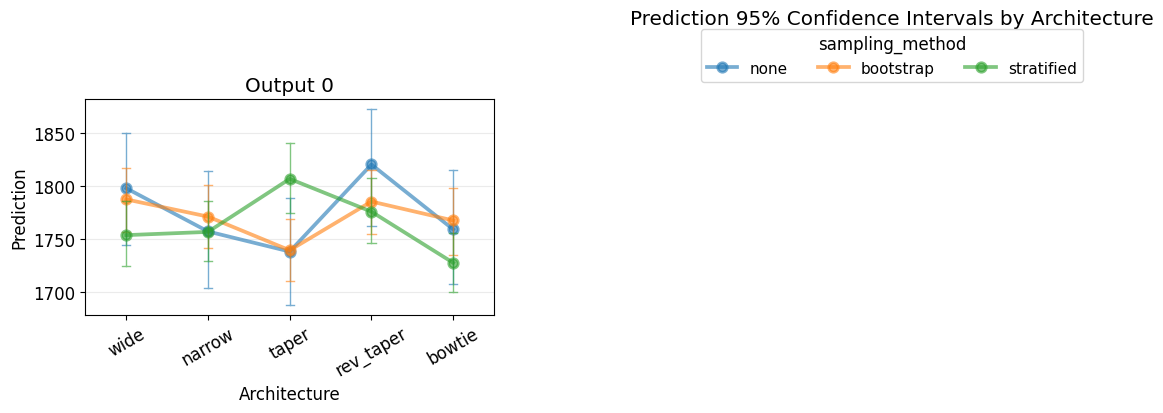

In [83]:
print(p_df.shape)
plot_predictions_by_output(p_df)

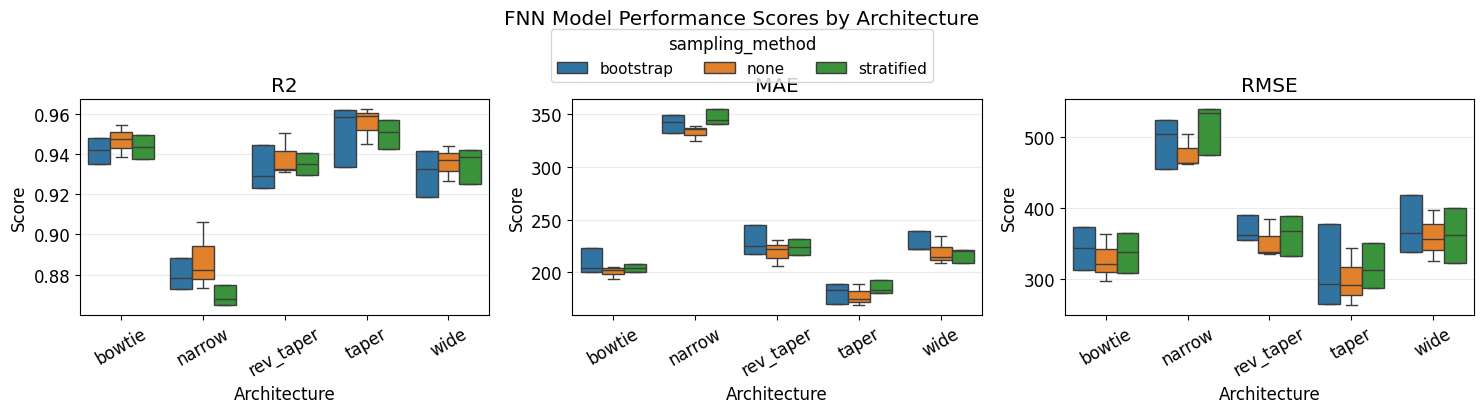

In [84]:
# Compare performance scores for trained FNN models.
plot_scores_by_metric(uq_df)

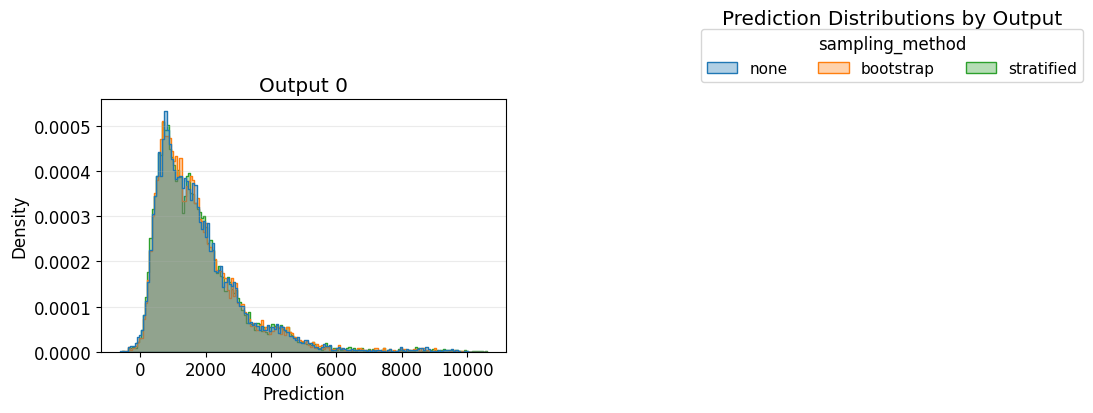

In [85]:
# Show prediction distributions for each output index.
plot_prediction_distributions_by_output(p_df)